# Exploratory Data Analysis
The goal is to understand dataset size, its properties: classes distribution, target, gaps, disbalance.

Data generated in `src/load_data.py`

In [4]:
# import libraries

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_from_disk

In [5]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cub_200_2011"

ds = load_from_disk(DATA_PATH)
class_names = ds["train"].features["label"].names

print(ds)
print("Number of classes:", len(class_names))

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'label'],
        num_rows: 5094
    })
    val: Dataset({
        features: ['image', 'image_id', 'label'],
        num_rows: 900
    })
    test: Dataset({
        features: ['image', 'image_id', 'label'],
        num_rows: 5794
    })
})
Number of classes: 200


## Class distribution and imbalance

In [6]:
counts = pd.DataFrame({
    split: pd.Series(ds[split]["label"]).value_counts().reindex(range(len(class_names)), fill_value=0)
    for split in ds
})
counts.index = class_names

summary = counts.describe().T[["count", "mean", "min", "max", "std"]]
summary["total"] = counts.sum()
summary["empty_classes"] = (counts == 0).sum()
summary["imbalance_ratio"] = counts.max() / counts.min()
summary

,count,mean,min,max,std,total,empty_classes,imbalance_ratio
train,200.0,25.47,25.0,26.0,0.500352,5094,0,1.040000
val,200.0,4.50,4.0,5.0,0.501255,900,0,1.250000
test,200.0,28.97,11.0,30.0,2.920917,5794,0,2.727273


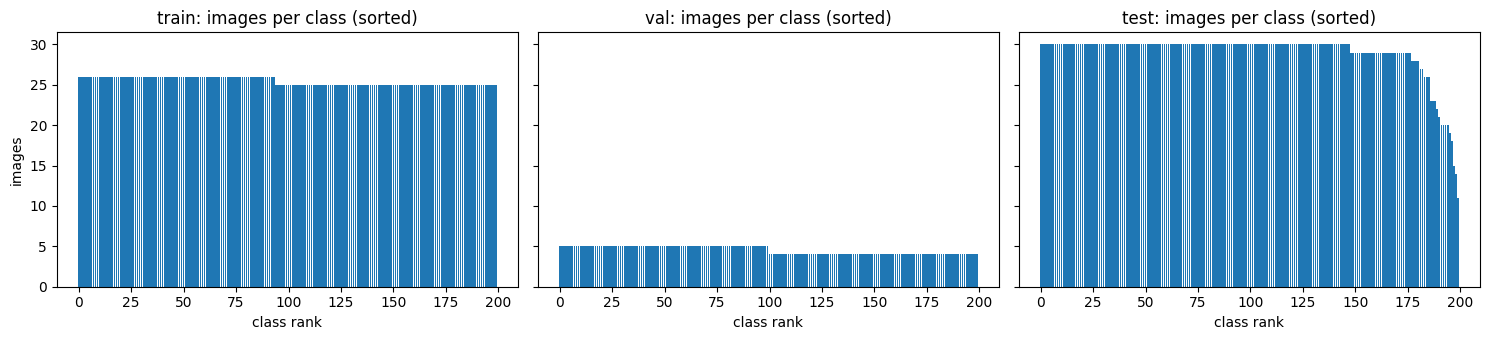

Smallest classes in train:
001.Black_footed_Albatross    25
003.Sooty_Albatross           25
004.Groove_billed_Ani         25
005.Crested_Auklet            25
006.Least_Auklet              25
008.Rhinoceros_Auklet         25
011.Rusty_Blackbird           25
015.Lazuli_Bunting            25
016.Painted_Bunting           25
017.Cardinal                  25
Name: train, dtype: int64


In [7]:
fig, axes = plt.subplots(1, len(ds), figsize=(15, 3.5), sharey=True)
for ax, split in zip(axes, ds):
    ax.bar(range(len(class_names)), counts[split].sort_values(ascending=False).values)
    ax.set_title(f"{split}: images per class (sorted)")
    ax.set_xlabel("class rank")
axes[0].set_ylabel("images")
plt.tight_layout()
plt.show()

print("Smallest classes in train:")
print(counts["train"].nsmallest(10))

## Missing values, corrupted images, leakage between splits

In [8]:
# decodes every image once: size, color mode and whether it is readable at all
rows = []
for split in ds:
    for i, ex in enumerate(ds[split]):
        img = ex["image"]
        rows.append({
            "split": split,
            "image_id": ex["image_id"],
            "label": ex["label"],
            "missing": img is None,
            "width": img.width if img is not None else None,
            "height": img.height if img is not None else None,
            "mode": img.mode if img is not None else None,
        })
meta = pd.DataFrame(rows)

print("Missing values per column:")
print(meta.isna().sum())
print("\nMissing images:", meta["missing"].sum())
print("Duplicate image_id:", meta["image_id"].duplicated().sum())
print("\nColor modes:")
print(meta.groupby("split")["mode"].value_counts())

Missing values per column:
split       0
image_id    0
label       0
missing     0
width       0
height      0
mode        0
dtype: int64

Missing images: 0
Duplicate image_id: 0

Color modes:
split  mode
test   RGB     5790
       L          4
train  RGB     5092
       L          2
val    RGB      898
       L          2
Name: count, dtype: int64


In [9]:
# exact-duplicate images (same bytes), incl. across splits = leakage
import hashlib

hashes = []
for split in ds:
    raw = ds[split].cast_column("image", ds[split].features["image"].__class__(decode=False))
    hashes += [(split, hashlib.md5(x["bytes"]).hexdigest()) for x in raw["image"]]
hashes = pd.DataFrame(hashes, columns=["split", "md5"])

dup = hashes[hashes["md5"].duplicated(keep=False)]
print("Duplicate images:", len(dup))
print("Duplicates spanning several splits:", (dup.groupby("md5")["split"].nunique() > 1).sum())

Duplicate images: 2
Duplicates spanning several splits: 0


## Image sizes

              width        height
count  11788.000000  11788.000000
mean     467.886834    386.029946
std       63.930494     70.890307
min      121.000000    120.000000
25%      495.000000    333.000000
50%      500.000000    375.000000
75%      500.000000    434.000000
max      500.000000    500.000000


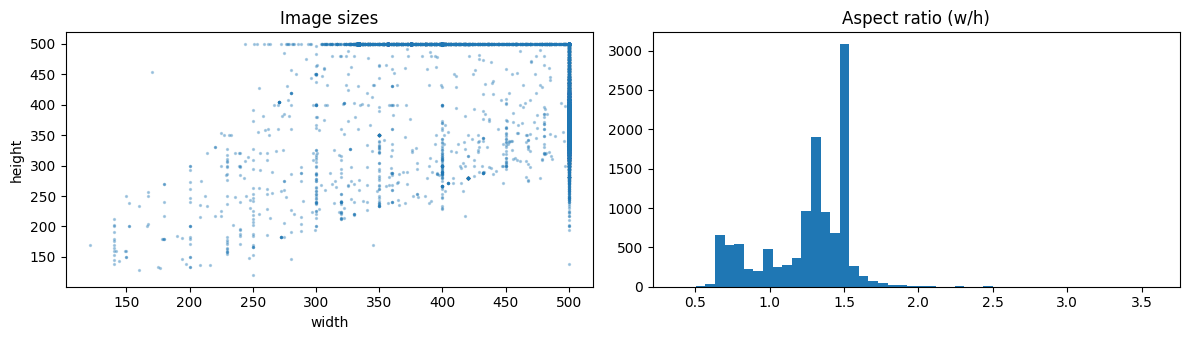

In [10]:
print(meta[["width", "height"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].scatter(meta["width"], meta["height"], s=2, alpha=0.3)
axes[0].set_xlabel("width"); axes[0].set_ylabel("height"); axes[0].set_title("Image sizes")
axes[1].hist(meta["width"] / meta["height"], bins=50)
axes[1].set_title("Aspect ratio (w/h)")
plt.tight_layout()
plt.show()

## Samples

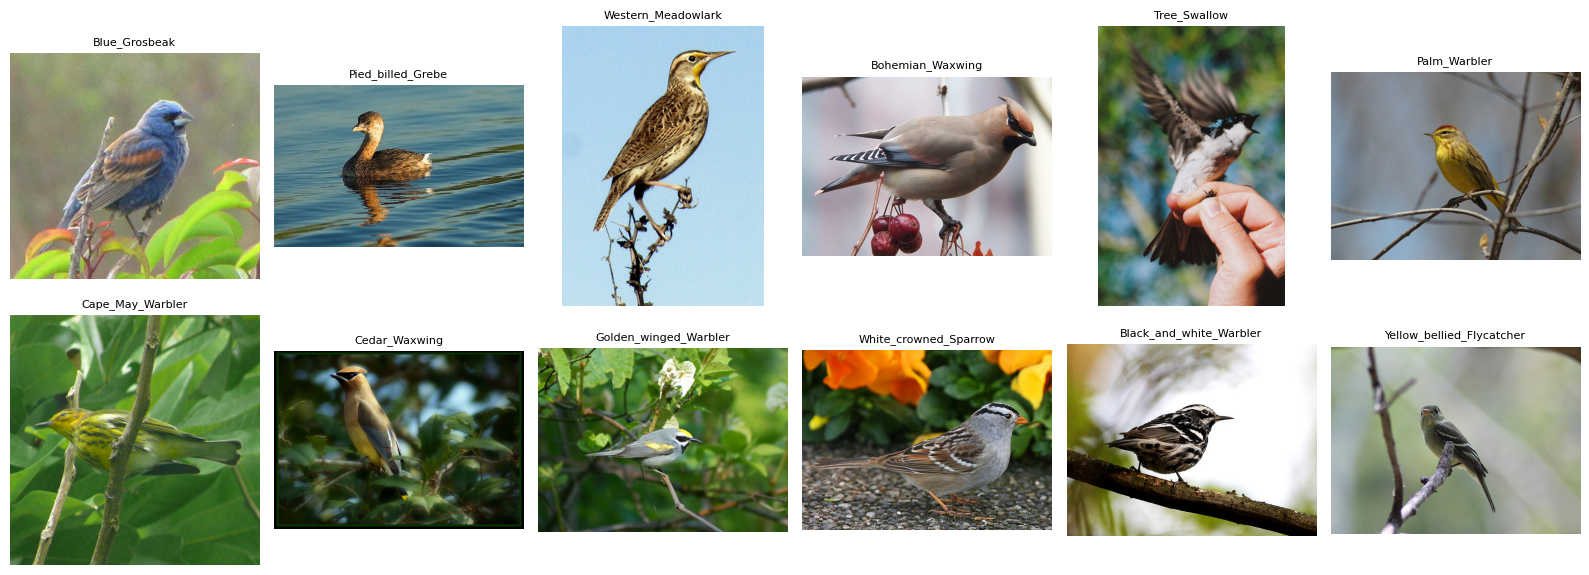

In [11]:
sample = ds["train"].shuffle(seed=42).select(range(12))
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for ax, ex in zip(axes.flat, sample):
    ax.imshow(ex["image"])
    ax.set_title(class_names[ex["label"]].split(".", 1)[1], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Conclusion
- There is almost no class disbalance in the dataset, no missing images.
- Some pictures are in a grayscale, so need to convert them to RGB during training
- Image size is different, so need to resize or crop
- 2 duplicate images found